# KMT Feature Classification — Enhanced Pipeline

**Pipeline overview**
1. Load all 88 user JSON files
2. Extract expanded keyboard + mouse features
3. Build one master dataframe combining all users
4. Normalize features
5. Train Random Forest, XGBoost, and Isolation Forest
6. Evaluate with ROC-AUC, confusion matrix, precision, recall
7. Save trained models with joblib

**Keyboard features extracted**
- Mean / Std / Max dwell time
- Typing speed (keys per second)
- Correction count (backspace presses)
- Backspace frequency (backspaces / total keys)
- Shift usage (shift/capslock presses / total keys)
- Total typing duration

**Mouse features extracted**
- Average velocity
- Acceleration
- Total distance
- Click count
- Hesitation (movement gaps > 0.5 s)
- Pauses (movement gaps > 1.0 s)
- Direction changes

## Step 1 — Libraries

In [1]:
import json
import math
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_score,
    recall_score,
)
from xgboost import XGBClassifier

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2 — Feature Extraction Functions

In [2]:
# ─────────────────────────────────────────────
#  KEYBOARD FEATURE EXTRACTION
# ─────────────────────────────────────────────

def extract_keyboard_features(session_data: dict) -> dict:
    """
    Given a session dict (true_data or false_data) with keys test_1…test_N,
    aggregate keyboard features across all tests and return a single feature dict.

    Features
    --------
    mean_dwell, std_dwell, max_dwell   : dwell-time statistics (ms)
    typing_speed                        : keystrokes per second
    correction_count                    : total backspace presses
    backspace_frequency                 : backspaces / total presses
    shift_usage                         : (shift + capslock) presses / total presses
    total_typing_duration               : total elapsed time from first press to last release (s)
    """
    all_dwell   = []
    total_presses      = 0
    backspace_count    = 0
    shift_count        = 0
    session_start      = None
    session_end        = None

    for test_key in session_data:
        if not test_key.startswith('test_'):
            continue
        k_events = session_data[test_key].get('key_events', [])

        # Remove tab events (kivy doesn't register tab releases)
        k_events = [e for e in k_events if e.get('Key') != 'tab']

        # Pair presses with their matching releases to compute dwell time
        press_index = {}  # key -> epoch of most recent press
        for event in k_events:
            key  = event.get('Key', '')
            typ  = event.get('Event', '')
            epoch = float(event.get('Epoch', 0))

            if session_start is None or epoch < session_start:
                session_start = epoch
            if session_end is None or epoch > session_end:
                session_end = epoch

            if typ == 'pressed':
                press_index[key] = epoch
                total_presses += 1
                lk = key.lower()
                if lk in ('backspace', '\b'):
                    backspace_count += 1
                if 'shift' in lk or 'caps' in lk:
                    shift_count += 1

            elif typ == 'released' and key in press_index:
                dwell = epoch - press_index.pop(key)
                if 0 < dwell < 2.0:   # sanity cap at 2 s
                    all_dwell.append(dwell * 1000)  # convert to ms

    # Typing speed: total presses / total duration
    total_duration = (session_end - session_start) if (session_start and session_end) else 0
    typing_speed   = total_presses / total_duration if total_duration > 0 else 0

    return {
        'mean_dwell'           : float(np.mean(all_dwell))   if all_dwell else 0.0,
        'std_dwell'            : float(np.std(all_dwell))    if all_dwell else 0.0,
        'max_dwell'            : float(np.max(all_dwell))    if all_dwell else 0.0,
        'typing_speed'         : typing_speed,
        'correction_count'     : backspace_count,
        'backspace_frequency'  : backspace_count / total_presses if total_presses > 0 else 0.0,
        'shift_usage'          : shift_count / total_presses if total_presses > 0 else 0.0,
        'total_typing_duration': total_duration,
    }

In [3]:
# ─────────────────────────────────────────────
#  MOUSE FEATURE EXTRACTION
# ─────────────────────────────────────────────

def _euclidean(a, b):
    return math.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)

def _angle(a, b):
    """Angle of vector from a to b in degrees."""
    dx, dy = b[0] - a[0], b[1] - a[1]
    return math.degrees(math.atan2(dy, dx))


def extract_mouse_features(session_data: dict) -> dict:
    """
    Given a session dict (true_data or false_data) with keys test_1…test_N,
    aggregate mouse features across all tests and return a single feature dict.

    Features
    --------
    avg_velocity        : average pixel/s across all movements
    acceleration        : average pixel/s² (mean absolute velocity change per dt)
    total_distance      : cumulative pixel distance across all movements
    click_count         : total left + right press events
    hesitation          : number of inter-event gaps between 0.5 s and 1.0 s
    pauses              : number of inter-event gaps > 1.0 s
    direction_changes   : number of times movement angle changes > 45 degrees
    """
    velocities         = []
    accelerations      = []
    total_distance     = 0.0
    click_count        = 0
    hesitation         = 0
    pauses             = 0
    direction_changes  = 0

    HESITATION_LO = 0.5   # seconds
    HESITATION_HI = 1.0   # seconds
    PAUSE_THRESH  = 1.0   # seconds
    DIR_THRESH    = 45.0  # degrees

    for test_key in session_data:
        if not test_key.startswith('test_'):
            continue
        m_events = session_data[test_key].get('mouse_events', [])

        # Filter out non-dict items (e.g. the trailing {false_enters: 1})
        m_events = [e for e in m_events if isinstance(e, dict) and 'Event' in e]

        prev_coord = None
        prev_epoch = None
        prev_angle = None
        prev_vel   = None

        for event in m_events:
            etype = event.get('Event', '')
            epoch = float(event.get('Epoch', 0))
            coord = event.get('Coordinates')

            # Count clicks
            if 'press' in etype and ('left' in etype or 'right' in etype):
                click_count += 1

            if etype == 'movement' and coord:
                if prev_coord is not None and prev_epoch is not None:
                    dt   = epoch - prev_epoch
                    dist = _euclidean(coord, prev_coord)
                    total_distance += dist

                    if dt > 0:
                        vel = dist / dt
                        velocities.append(vel)

                        # Acceleration: rate of velocity change
                        if prev_vel is not None:
                            accelerations.append(abs(vel - prev_vel) / dt)
                        prev_vel = vel

                        # Hesitation and pauses are based on time gaps
                        if HESITATION_LO <= dt < HESITATION_HI:
                            hesitation += 1
                        elif dt >= PAUSE_THRESH:
                            pauses += 1

                    # Direction change
                    if dist > 1e-6:  # ignore jitter
                        angle = _angle(prev_coord, coord)
                        if prev_angle is not None:
                            delta = abs(angle - prev_angle)
                            if delta > 180:
                                delta = 360 - delta
                            if delta > DIR_THRESH:
                                direction_changes += 1
                        prev_angle = angle

                prev_coord = coord
                prev_epoch = epoch

    return {
        'avg_velocity'     : float(np.mean(velocities))      if velocities     else 0.0,
        'acceleration'     : float(np.mean(accelerations))   if accelerations  else 0.0,
        'total_distance'   : total_distance,
        'click_count'      : click_count,
        'hesitation'       : hesitation,
        'pauses'           : pauses,
        'direction_changes': direction_changes,
    }

## Step 3 — Build Master DataFrame (all 88 users)

In [4]:
# ── Configure path ──────────────────────────────────────────────────────────
# Set DATASET_PATH to the folder containing raw_kmt_user_XXXX.json files.
DATASET_PATH = '/content/raw_kmt_dataset'   # <-- adjust if needed

# ── Collect rows ─────────────────────────────────────────────────────────────
rows = []
missing_files = []

for user_number in range(1, 89):
    file_name = f'raw_kmt_user_{user_number:04d}.json'
    file_path = os.path.join(DATASET_PATH, file_name)

    if not os.path.exists(file_path):
        missing_files.append(file_name)
        continue

    with open(file_path, 'r') as f:
        data = json.load(f)

    for split, label in [('true_data', 1), ('false_data', 0)]:
        session = data.get(split, {})
        kb  = extract_keyboard_features(session)
        mse = extract_mouse_features(session)
        row = {'user_id': user_number, 'label': label, **kb, **mse}
        rows.append(row)

if missing_files:
    print(f'Warning: {len(missing_files)} file(s) not found — {missing_files[:5]}...')

master_df = pd.DataFrame(rows)
print(f'Master DataFrame shape: {master_df.shape}')
print(f'Label distribution:\n{master_df["label"].value_counts()}')
master_df.head()

Master DataFrame shape: (176, 17)
Label distribution:
label
1    88
0    88
Name: count, dtype: int64


,user_id,label,mean_dwell,std_dwell,max_dwell,typing_speed,correction_count,backspace_frequency,shift_usage,total_typing_duration,avg_velocity,acceleration,total_distance,click_count,hesitation,pauses,direction_changes
0,1,1,91.198833,33.893860,340.023756,2.767809,21,0.045259,0.066810,1.676416e+02,742.586086,37245.307269,8771.033762,35,1,11,62
1,1,0,101.504097,56.950882,473.093033,0.000436,21,0.042339,0.120968,1.137624e+06,372.868695,28980.673964,17964.716918,71,15,45,389
2,2,1,77.594462,34.729583,301.023960,1.559761,49,0.097416,0.065606,3.224854e+02,750.096947,36916.362344,47917.050302,82,32,65,394
3,2,0,99.987606,54.843249,529.384136,0.000418,24,0.050420,0.115546,1.137637e+06,388.937794,31660.903293,16460.698042,66,24,41,360
4,3,1,107.032981,77.810719,687.761545,1.287722,14,0.021739,0.335404,5.001080e+02,341.692516,16245.797836,26380.196119,74,32,47,518


In [5]:
# Quick summary statistics
master_df.describe().round(3)

,user_id,label,mean_dwell,std_dwell,max_dwell,typing_speed,correction_count,backspace_frequency,shift_usage,total_typing_duration,avg_velocity,acceleration,total_distance,click_count,hesitation,pauses,direction_changes
count,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,1.760000e+02,176.000,176.000,176.000,176.000,176.000
mean,44.500,0.500,115.402,51.994,536.199,0.598,28.574,0.049,0.098,1425117.638,441.449,2.089767e+05,19575.048,66.176,13.602,46.477,444.602
std,25.474,0.501,19.981,20.409,275.303,0.707,45.816,0.054,0.067,1606034.849,105.854,1.454297e+06,8890.902,23.089,6.802,20.831,218.258
min,1.000,0.000,68.380,15.119,135.987,0.000,0.000,0.000,0.000,167.642,225.829,1.041208e+04,5900.166,30.000,1.000,10.000,62.000
25%,22.750,0.000,101.360,36.121,352.370,0.000,8.000,0.018,0.066,404.116,368.310,3.529494e+04,14360.131,53.000,9.000,34.000,298.750
50%,44.500,0.500,117.897,52.394,517.656,0.165,15.500,0.033,0.094,88207.980,431.282,5.367488e+04,17206.226,64.000,12.000,43.500,407.000
75%,66.250,1.000,127.675,65.279,627.827,1.162,30.250,0.061,0.129,3204259.800,491.425,7.731653e+04,21838.333,75.000,16.000,57.000,516.500
max,88.000,1.000,188.787,127.760,1739.669,2.824,382.000,0.374,0.418,3796595.279,910.955,1.839328e+07,70742.449,177.000,46.000,159.000,1702.000


In [25]:
# Diagnostic — check for trivially separable features
print(master_df.groupby('label')[FEATURE_COLS].mean().T.round(3))
print()

# Check if any single feature perfectly separates the classes
for col in FEATURE_COLS:
    genuine = master_df[master_df['label']==1][col]
    impostor = master_df[master_df['label']==0][col]
    overlap = not (genuine.min() > impostor.max() or impostor.min() > genuine.max())
    print(f'{col:30s}  overlap={overlap}  genuine=[{genuine.min():.2f}, {genuine.max():.2f}]  impostor=[{impostor.min():.2f}, {impostor.max():.2f}]')

label                         0           1
mean_dwell              114.471     116.334
std_dwell                55.863      48.124
max_dwell               596.692     475.706
typing_speed              0.000       1.196
correction_count         28.977      28.170
backspace_frequency       0.050       0.048
shift_usage               0.100       0.097
avg_velocity            424.004     458.893
acceleration         138609.388  279344.053
total_distance        18950.372   20199.725
click_count              65.455      66.898
hesitation               13.648      13.557
pauses                   44.580      48.375
direction_changes       437.989     451.216

mean_dwell                      overlap=True  genuine=[68.38, 188.79]  impostor=[95.23, 132.80]
std_dwell                       overlap=True  genuine=[15.12, 127.76]  impostor=[33.28, 96.98]
max_dwell                       overlap=True  genuine=[135.99, 1637.78]  impostor=[232.23, 1739.67]
typing_speed                    overlap=False  g

## Step 4 — Feature Normalization

In [38]:
from sklearn.model_selection import GroupShuffleSplit
FEATURE_COLS = [
    # Keyboard
    'mean_dwell', 'std_dwell', 'max_dwell',
    'correction_count', 'backspace_frequency',
    'shift_usage',
    # 'typing_speed',            ← removed: always 0 for impostors (corrupt epochs)
    # 'total_typing_duration',   ← removed: corrupt epochs in false_data
    # Mouse
    'avg_velocity', 'acceleration', 'total_distance',
    'click_count', 'hesitation', 'pauses', 'direction_changes',
]

X = master_df[FEATURE_COLS]
y = master_df['label']

# Check for NaN
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f'NaN detected in: {nan_cols}  — filling with column median')
    X = X.fillna(X.median())

# Normalize with StandardScaler — fit on train, apply to test


groups = master_df['user_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4b  Calibrated models ─────────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    method='isotonic', cv=3
)
rf_calibrated.fit(X_train_scaled, y_train)

xgb_calibrated = CalibratedClassifierCV(
    XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, eval_metric='logloss'),
    method='isotonic', cv=3
)
xgb_calibrated.fit(X_train_scaled, y_train)

print(f'Train size: {X_train_scaled.shape}  |  Test size: {X_test_scaled.shape}')
print(f'Train label distribution: {pd.Series(y_train).value_counts().to_dict()}')

Train size: (140, 13)  |  Test size: (36, 13)
Train label distribution: {1: 70, 0: 70}


## Step 5 — Training

In [47]:
# ── Shared evaluation helper ─────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    """Fit, predict, then print and return a results dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if proba:
        y_prob = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_prob)
    else:
        y_prob = None
        auc = None

    prec   = precision_score(y_te, y_pred, zero_division=0)
    rec    = recall_score(y_te, y_pred, zero_division=0)
    cm     = confusion_matrix(y_te, y_pred)

    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_te, y_pred, target_names=['Impostor (0)', 'Genuine (1)']))
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    if auc is not None:
        print(f'  ROC-AUC   : {auc:.4f}')

    return {'name': name, 'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
            'precision': prec, 'recall': rec, 'auc': auc, 'cm': cm}

### 5a — Random Forest

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_results = evaluate_model('Random Forest', rf_calibrated,
                             X_train_scaled, y_train,
                             X_test_scaled,  y_test)


  Random Forest
              precision    recall  f1-score   support

Impostor (0)       0.90      1.00      0.95        18
 Genuine (1)       1.00      0.89      0.94        18

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.94        36
weighted avg       0.95      0.94      0.94        36

  Precision : 1.0000
  Recall    : 0.8889
  ROC-AUC   : 0.9645


### 5b — XGBoost

In [49]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

xgb_results = evaluate_model('XGBoost', xgb_calibrated,
                              X_train_scaled, y_train,
                              X_test_scaled,  y_test)


  XGBoost
              precision    recall  f1-score   support

Impostor (0)       0.82      1.00      0.90        18
 Genuine (1)       1.00      0.78      0.88        18

    accuracy                           0.89        36
   macro avg       0.91      0.89      0.89        36
weighted avg       0.91      0.89      0.89        36

  Precision : 1.0000
  Recall    : 0.7778
  ROC-AUC   : 0.9475


### 5c — Isolation Forest  
*Unsupervised anomaly-detection — trained on genuine (label=1) samples only; predicts -1 for outliers (impostors) and 1 for inliers (genuine). Labels are remapped to 0/1 for a consistent evaluation.*

## Step 6 — Visualisations

In [50]:
# ── 5d  Risk Score ────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler as MMS

y_prob_rf  = rf_calibrated.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb_calibrated.predict_proba(X_test_scaled)[:, 1]



# Weighted ensemble (RF + XGBoost trusted more than IsoForest)
genuine_prob = (0.50 * y_prob_rf) + (0.50 * y_prob_xgb)
risk_score   = 1 - genuine_prob   # flip: 1 = high risk, 0 = safe

def risk_band(score):
    if score < 0.3:   return 'LOW'
    elif score < 0.6: return 'MEDIUM'
    else:             return 'HIGH'

risk_df = pd.DataFrame({
    'user_id'      : master_df.iloc[test_idx]['user_id'].values,
    'true_label'   : y_test.values,
    'genuine_prob' : y_prob_rf.round(3),
    'risk_score'   : risk_score.round(3),
    'risk_band'    : [risk_band(s) for s in risk_score],
})

print(risk_df.to_string(index=False))
print()
print(risk_df['risk_band'].value_counts())

 user_id  true_label  genuine_prob  risk_score risk_band
       1           1         1.000       0.028       LOW
       1           0         0.071       0.876      HIGH
       5           1         0.800       0.167       LOW
       5           0         0.000       0.853      HIGH
      11           1         1.000       0.056       LOW
      11           0         0.067       0.899      HIGH
      13           1         1.000       0.028       LOW
      13           0         0.254       0.705      HIGH
      19           1         1.000       0.067       LOW
      19           0         0.044       0.903      HIGH
      23           1         1.000       0.006       LOW
      23           0         0.168       0.711      HIGH
      27           1         0.800       0.167       LOW
      27           0         0.240       0.675      HIGH
      34           1         1.000       0.000       LOW
      34           0         0.138       0.802      HIGH
      54           1         1.

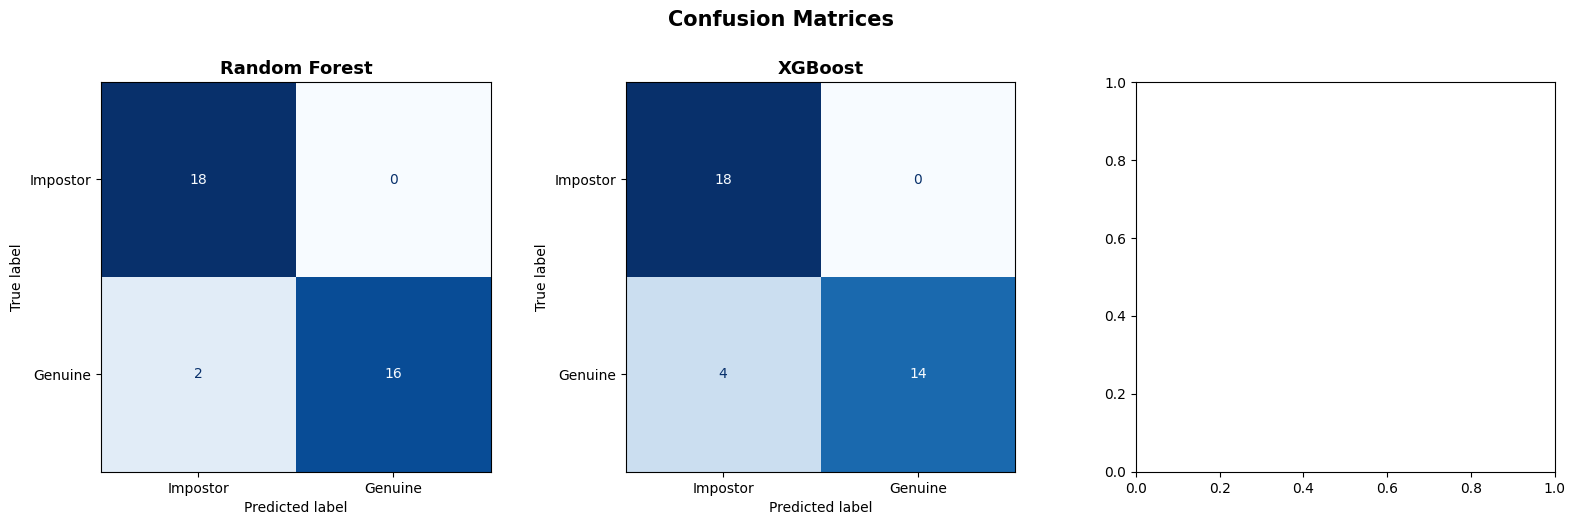

In [52]:
# ── Confusion matrices ────────────────────────────────────────────────────────
all_results = [rf_results, xgb_results,]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res in zip(axes, all_results):
    disp = ConfusionMatrixDisplay(res['cm'], display_labels=['Impostor', 'Genuine'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['name'], fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

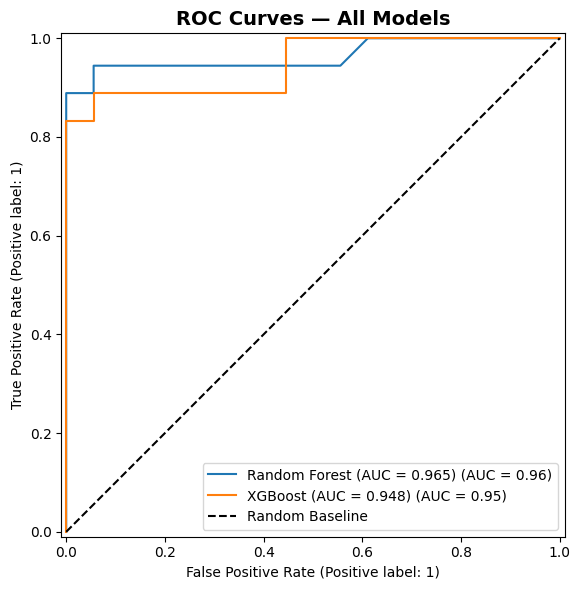

In [53]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for res in all_results:
    if res['y_prob'] is not None:
        label = f"{res['name']} (AUC = {res['auc']:.3f})"
        RocCurveDisplay.from_predictions(
            y_test, res['y_prob'], name=label, ax=ax
        )

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

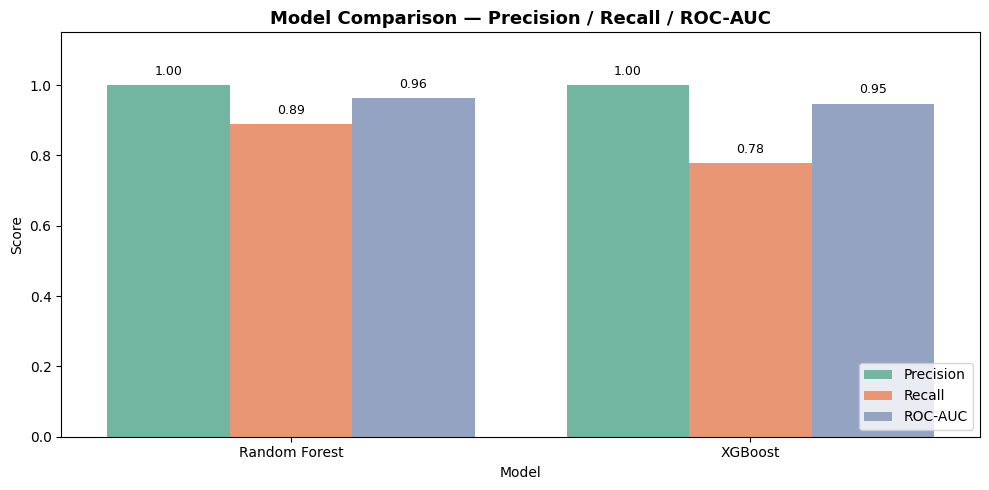

        Model  Precision   Recall  ROC-AUC
Random Forest        1.0 0.888889 0.964506
      XGBoost        1.0 0.777778 0.947531


In [54]:
# ── Metric comparison bar chart ───────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model'    : r['name'],
        'Precision': r['precision'],
        'Recall'   : r['recall'],
        'ROC-AUC'  : r['auc'] if r['auc'] else 0,
    }
    for r in all_results
])

summary_melted = summary.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=summary_melted, x='Model', y='Score', hue='Metric', ax=ax, palette='Set2')
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison — Precision / Recall / ROC-AUC', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
for bar in ax.patches:
    h = bar.get_height()
    if h > 0.01:                          # skip ghost/empty bars
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.02,
            f'{h:.2f}',
            ha='center', va='bottom', fontsize=9
        )
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(summary.to_string(index=False))

In [55]:
# ── Feature importances (Random Forest) ──────────────────────────────────────
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Step 7 — Save Trained Models

In [56]:
os.makedirs('saved_models', exist_ok=True)

joblib.dump(rf_model,  'saved_models/random_forest.joblib')
joblib.dump(xgb_model, 'saved_models/xgboost.joblib')
joblib.dump(scaler,    'saved_models/scaler.joblib')
# add these two lines alongside the existing saves
joblib.dump(rf_calibrated,  'saved_models/random_forest_calibrated.joblib')
joblib.dump(xgb_calibrated, 'saved_models/xgboost_calibrated.joblib')

# Save feature column order so loading code knows the expected input layout
joblib.dump(FEATURE_COLS, 'saved_models/feature_cols.joblib')

print('Models saved to ./saved_models/')
for f in os.listdir('saved_models'):
    path = os.path.join('saved_models', f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:40s}  {size_kb:8.1f} KB')

Models saved to ./saved_models/
  scaler.joblib                                  1.3 KB
  xgboost_calibrated.joblib                    598.4 KB
  random_forest.joblib                           0.6 KB
  xgboost.joblib                                 0.8 KB
  feature_cols.joblib                            0.2 KB
  random_forest_calibrated.joblib             1502.6 KB


## Loading a saved model (example)

In [58]:
# ── Step 7  Save models ───────────────────────────────────────────────
os.makedirs('saved_models', exist_ok=True)

joblib.dump(rf_model,          'saved_models/random_forest.joblib')
joblib.dump(xgb_model,         'saved_models/xgboost.joblib')
joblib.dump(rf_calibrated,     'saved_models/random_forest_calibrated.joblib')
joblib.dump(xgb_calibrated,    'saved_models/xgboost_calibrated.joblib')
joblib.dump(scaler,            'saved_models/scaler.joblib')
joblib.dump(FEATURE_COLS,      'saved_models/feature_cols.joblib')

print('Models saved to ./saved_models/')
for f in os.listdir('saved_models'):
    path = os.path.join('saved_models', f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:45s}  {size_kb:8.1f} KB')

Models saved to ./saved_models/
  scaler.joblib                                       1.3 KB
  xgboost_calibrated.joblib                         598.4 KB
  random_forest.joblib                                0.6 KB
  xgboost.joblib                                      0.8 KB
  feature_cols.joblib                                 0.2 KB
  isolation_forest.joblib                          1121.4 KB
  random_forest_calibrated.joblib                  1502.6 KB


In [59]:
master_df.to_csv('master_df.csv', index=False)